Run: 1
Preparing GPs...
Seed: 21
max iterations: 100
initial points: 100


Iteration 1
mu: -0.7049445839898925, sigma: 0.8780461824813242, best: -1.6737656540668935, xi: 1.0, z: -2.242275072902105, ei: 0.003801917158396579, prob1: [0.71792126], prob2: [0.79183397], prob3: [0.83059641], EI: [0.00179516]
Optimized Kernel Y: RBF(length_scale=[0.5, 0.5, 0.5, 0.5, 0.5, 0.5])
Optimized Kernel freq1: RBF(length_scale=[0.5, 0.5, 0.5, 0.5, 0.5, 0.5])
Optimized Kernel freq2: RBF(length_scale=[0.5, 0.5, 0.5, 0.5, 0.5, 0.5])
Optimized Kernel freq3: RBF(length_scale=[0.5, 0.5, 0.5, 0.5, 0.5, 0.5])

height: [0.77289631 1.89807222 2.41177106 2.28723651 2.43683554]
area: [0.00200826]
weight: 877.7441871577689
freq1: 31.334567049929273
freq2: 60.9016251047661
freq3: 82.62792021415252


Iteration 2
mu: -0.7990699351765023, sigma: 0.806527082549146, best: -1.6737656540668935, xi: 0.985, z: -2.305806905710774, ei: 0.0029033250950554687, prob1: [0.82510631], prob2: [0.86790024], prob3: [0.90923706], EI: [0

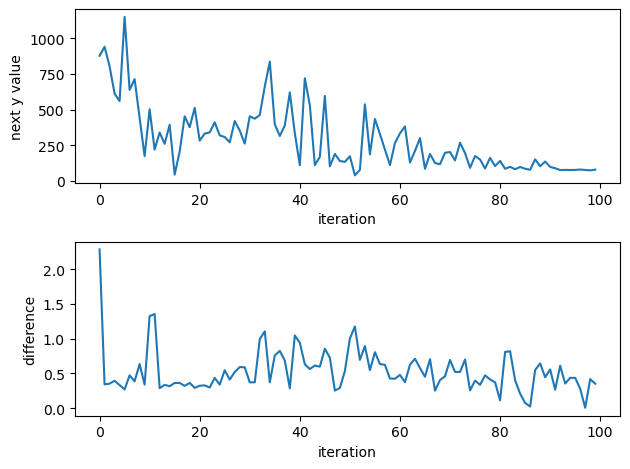



Best values
time: 75.84360241889954
height: [1.19868076 1.73102341 1.76016901 2.10647164 2.51878595]
area: [0.00017239]
weight: 72.08815613399884
freq1: 22.345763038572745
freq2: 42.69980545194607
freq3: 60.5806577978371




In [15]:
import numpy as np
import time
from scipy.optimize import minimize, differential_evolution
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel, RationalQuadratic, DotProduct
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt

import sys
sys.path.append('../pyJive/')

from utils import proputils as pu
import main
from names import GlobNames as gn
from names import ParamNames as pn

import io
import contextlib


def update_geom_file(geom_path, y_coord, update_lines, output_path=None):
    output_path = output_path or geom_path  # Overwrite if no output path provided

    # Read the .geom file
    with open(geom_path, 'r') as file:
        lines = file.readlines()

    # Locate and modify the section with upper node coordinates
    for i in range(len(lines)):
        if i in update_lines:
            parts = lines[i].split()
            
            parts[-1] = str(y_coord)  # Modify the last value
            lines[i] = ' '.join(parts) + '\n'        
            
    # Write back the updated file
    with open(output_path, 'w') as file:
        file.writelines(lines)
        

def finite_element_solver(x, n_heights, n_areas):
    # DOES ONLY WORK FOR 6 DIMENSIONS
    y_coord = x[:n_heights]
    area = x[n_heights:]
    update_lines = [[3, 19], [5, 17], [7, 15], [9, 13], [11,]]
    
    for i in range(n_heights):
        update_geom_file('bridge.geom', y_coord[i], update_lines[i], output_path=None)
    
    # Load properties
    props = pu.parse_file('bridge_frequency.pro')
    
    # Update cross-section area
    props['model']['truss']['area'] = [area] * 15
    # props['model']['truss']['area'] = [4e-3] + [area] * 14 
    
    # Run FEM simulation
    with contextlib.redirect_stdout(io.StringIO()):
        globdat = main.jive(props)

    # Extract mass  
    mass_nodes = props['model']['mass']['nodeGroup']
    n_bottom_nodes = len(globdat[gn.NGROUPS][mass_nodes])
    point_mass = float(props['model']['mass']['mass'])
    weight = 0.5 * np.sum(globdat[pn.MATRIX2]) - n_bottom_nodes * point_mass
    
    # Extract natural frequencies
    freq1 = globdat[gn.EIGENFREQS][0] / (2 * np.pi)
    freq2 = globdat[gn.EIGENFREQS][1] / (2 * np.pi)
    freq3 = globdat[gn.EIGENFREQS][2] / (2 * np.pi)

    return weight, freq1, freq2, freq3


def feasibility_probability(x, gp_freq, threshold):
    mu, sigma = gp_freq.predict(x.reshape(1, -1), return_std=True)
    prob = norm.cdf((threshold - mu) / (sigma + 1e-9))
    
    return prob


def EI(x, gp_Y, gp_freq1, gp_freq2, gp_freq3, Y_samples, threshold1, threshold2, threshold3, input_scaler, output_scaler, n_dim, xi):
    mu, sigma = gp_Y.predict(x.reshape(1, -1), return_std=True)
    mu, sigma = mu[0], sigma[0]
    best = np.min(Y_samples)
    
    # Expected Improvement (EI)
    # xi<0: Encourages exploitation (improving known, minimal regions)
    # xi>0: Encourages exploration (exploring regions with high uncertainty)
    # xi = -1.5
    z = (best - mu - xi) / (sigma + 1e-9)
    ei = (best - mu - xi) * norm.cdf(z) + sigma * norm.pdf(z)
    
    prob1 = 1 - feasibility_probability(x, gp_freq1, threshold1)
    prob2 = 1 - feasibility_probability(x, gp_freq2, threshold2)
    prob3 = 1 - feasibility_probability(x, gp_freq3, threshold3)
    
    # print('x', input_scaler.inverse_transform(x.reshape(-1, n_dim))[0])
    # print('mu', output_scaler.inverse_transform(mu.reshape(-1, 1))[0, 0])
    print(f"mu: {mu}, sigma: {sigma}, best: {best}, xi: {xi}, z: {z}, ei: {ei}, prob1: {prob1}, prob2: {prob2}, prob3: {prob3}, EI: {ei * prob1 * prob2 * prob3}")
    
    return -ei * prob1 * prob2 * prob3
    
    
def restart_differential_evolution(acquisition_func, bounds, n_restarts=3):
    best_x = None
    best_value = float('inf')
    
    for restart in range(n_restarts):
        result = differential_evolution(
            lambda x: acquisition_func(x), 
            bounds=bounds, 
            strategy='best1bin', 
            popsize=5,  # 5 * 19 = 95 population size
            maxiter=10,  # Small maxiter, we restart after 10 iterations
            tol=1e-6, 
            polish=True
        )
        if result.fun < best_value:
            best_value = result.fun
            best_x = result.x

        # print(f"Restart {restart + 1}/{n_restarts}, Best Value: {best_value}")
    
    return best_x


def hybrid_acquisition_optimization(acquisition_func, bounds):
    # Step 1: Global search with Differential Evolution
    result_de = differential_evolution(lambda x: acquisition_func(x), 
                                       bounds=bounds, 
                                       strategy='best1bin', 
                                       popsize=5,  # 5 * dim
                                       maxiter=10, 
                                       tol=1e-6, 
                                       polish=False)  # Do not polish with DE
    
    # Step 2: Local refinement with L-BFGS-B
    result_l_bfgs = minimize(acquisition_func, 
                             result_de.x, 
                             method='L-BFGS-B', 
                             bounds=bounds, 
                             options={'maxiter': 100, 'ftol': 1e-6})
    
    return result_l_bfgs.x

def adaptive_xi_linear(iteration, max_iterations, xi_max=2.0, xi_min=0.1):
    """Linearly decreases xi from xi_max to xi_min."""
    return xi_max - (xi_max - xi_min) * (iteration / max_iterations)


def bayesian_optimization(n_iter=100):   
    seed = 21
    # np.random.seed(seed)
    
    n_heights = 5
    n_areas = 1
    n_dim = n_heights + n_areas
    
    n_init = 100
    
    print('Preparing GPs...')
    print(f'Seed: {seed}')
    print(f'max iterations: {n_iter}')
    print(f'initial points: {n_init}')
    
    bounds_height_unscaled = np.tile([0.2, 3], (n_heights, 1))
    bounds_area_unscaled = np.tile([1e-5, 1e-2], (n_areas, 1))
    bounds_unscaled = np.vstack((bounds_height_unscaled, bounds_area_unscaled))
    
    threshold1_unscaled = 20
    threshold2_unscaled = 40
    threshold3_unscaled = 60
    
    X_height_unscaled = np.random.uniform(bounds_height_unscaled[0][0], bounds_height_unscaled[0][1], size=(n_init, n_heights))
    X_area_unscaled = np.random.uniform(bounds_area_unscaled[0][0], bounds_area_unscaled[0][1], size=(n_init, n_areas))
    X_samples_unscaled = np.column_stack((X_height_unscaled, X_area_unscaled))
    
    with contextlib.redirect_stdout(io.StringIO()):
        output = np.array([finite_element_solver(x, n_heights, n_areas) for x in X_samples_unscaled])
    
    Y_samples_unscaled = output[:, 0]
    freq1_samples_unscaled = output[:, 1]
    freq2_samples_unscaled = output[:, 2]
    freq3_samples_unscaled = output[:, 3]
    
    input_scaler = StandardScaler()
    output_scaler = StandardScaler()
    freq1_scaler = StandardScaler()
    freq2_scaler = StandardScaler()
    freq3_scaler = StandardScaler()
    
    X_samples = input_scaler.fit_transform(X_samples_unscaled)
    Y_samples = output_scaler.fit_transform(Y_samples_unscaled.reshape(-1, 1)).flatten()
    freq1_samples = freq1_scaler.fit_transform(freq1_samples_unscaled.reshape(-1, 1)).flatten()
    freq2_samples = freq2_scaler.fit_transform(freq2_samples_unscaled.reshape(-1, 1)).flatten()
    freq3_samples = freq3_scaler.fit_transform(freq3_samples_unscaled.reshape(-1, 1)).flatten()
    
    bounds = input_scaler.transform(bounds_unscaled.T).T
    threshold1 = freq1_scaler.transform(np.array(threshold1_unscaled).reshape(-1, 1))[0, 0]
    threshold2 = freq2_scaler.transform(np.array(threshold2_unscaled).reshape(-1, 1))[0, 0]
    threshold3 = freq3_scaler.transform(np.array(threshold3_unscaled).reshape(-1, 1))[0, 0]
    
    kernel_Y = RBF(length_scale=[0.5] * 6)
    kernel_freq1 = RBF(length_scale=[0.5] * 6)
    kernel_freq2 = RBF(length_scale=[0.5] * 6)
    kernel_freq3 = RBF(length_scale=[0.5] * 6)
    
    gp_Y = GaussianProcessRegressor(kernel=kernel_Y, optimizer=None, alpha=0)
    gp_freq1 = GaussianProcessRegressor(kernel=kernel_freq1, optimizer=None, alpha=0)
    gp_freq2 = GaussianProcessRegressor(kernel=kernel_freq2, optimizer=None, alpha=0)
    gp_freq3 = GaussianProcessRegressor(kernel=kernel_freq3, optimizer=None, alpha=0)
    
    y_next_list = []
    x_difference_list = []
    for iteration in range(n_iter):
    
        print('')
        print('')
        print(f'Iteration {iteration + 1}')

        gp_Y.fit(X_samples, Y_samples)
        gp_freq1.fit(X_samples, freq1_samples)
        gp_freq2.fit(X_samples, freq2_samples)
        gp_freq3.fit(X_samples, freq3_samples)
        
        xi = adaptive_xi_linear(iteration, n_iter, xi_max=1, xi_min=-0.5)
        
        def acquisition(x):
            return EI(x, gp_Y, gp_freq1, gp_freq2, gp_freq3, Y_samples, threshold1, threshold2, threshold3, input_scaler, output_scaler, n_dim, xi)
        
        with contextlib.redirect_stdout(io.StringIO()):
            # x_next = minimize(acquisition, np.random.uniform(bounds[0][0], bounds[0][1], 1), bounds=bounds).x
            # x_next = differential_evolution(acquisition, bounds=bounds).x
            # x_next = differential_evolution(lambda x: acquisition(x), 
            #                             bounds=bounds, 
            #                             strategy='best1bin', 
            #                             popsize=5, 
            #                             maxiter=10, 
            #                             tol=1e-6, 
            #                             polish=True).x
            # x_next = restart_differential_evolution(acquisition, bounds)
            x_next = hybrid_acquisition_optimization(acquisition, bounds)

        x_next_unscaled = input_scaler.inverse_transform(x_next.reshape(-1, n_dim))[0]
        
        EI_next = acquisition(x_next)
        y_next_unscaled = finite_element_solver(x_next_unscaled, n_heights, n_areas)[0]
        freq1_next_unscaled = finite_element_solver(x_next_unscaled, n_heights, n_areas)[1]
        freq2_next_unscaled = finite_element_solver(x_next_unscaled, n_heights, n_areas)[2]
        freq3_next_unscaled = finite_element_solver(x_next_unscaled, n_heights, n_areas)[3]
        
        y_next = output_scaler.transform(y_next_unscaled.reshape(-1, 1))[0]
        freq1_next = freq1_scaler.transform(freq1_next_unscaled.reshape(-1, 1))[0]
        freq2_next = freq2_scaler.transform(freq2_next_unscaled.reshape(-1, 1))[0]
        freq3_next = freq3_scaler.transform(freq3_next_unscaled.reshape(-1, 1))[0]
        
        X_samples = np.vstack((X_samples, x_next))
        Y_samples = np.append(Y_samples, y_next)        
        freq1_samples = np.append(freq1_samples, freq1_next)
        freq2_samples = np.append(freq2_samples, freq2_next)
        freq3_samples = np.append(freq3_samples, freq3_next)
        
        x_previous = X_samples[-2]
        x_difference_norm = np.abs((x_next - x_previous) / (bounds[:,1] - bounds[:,0])) 
        x_difference_list.append(sum(x_difference_norm))
        y_next_list.append(y_next_unscaled)
        
        print("Optimized Kernel Y:", gp_Y.kernel_)
        print("Optimized Kernel freq1:", gp_freq1.kernel_)
        print("Optimized Kernel freq2:", gp_freq2.kernel_)
        print("Optimized Kernel freq3:", gp_freq3.kernel_)
        print('')
        print(f'height: {x_next_unscaled[:n_heights]}')
        print(f'area: {x_next_unscaled[n_heights:]}')
        print(f'weight: {y_next_unscaled}')
        print(f'freq1: {freq1_next_unscaled}')
        print(f'freq2: {freq2_next_unscaled}')
        print(f'freq3: {freq3_next_unscaled}')
        
    fig, axs = plt.subplots(2) 
    axs[0].plot(y_next_list)
    axs[0].set_xlabel('iteration')
    axs[0].set_ylabel('next y value')
    axs[1].plot(x_difference_list)
    axs[1].set_xlabel('iteration')
    axs[1].set_ylabel('difference')
    plt.tight_layout()
    plt.show()
    
    valid_idx = np.where((freq1_samples >= threshold1) & (freq2_samples >= threshold2) & (freq3_samples >= threshold3))[0]
    best_idx = valid_idx[np.argmin(Y_samples[valid_idx])]
    best_x_unscaled = input_scaler.inverse_transform(X_samples[best_idx].reshape(-1, n_dim))[0]
    best_y_unscaled = output_scaler.inverse_transform(Y_samples[best_idx].reshape(-1, 1))[0, 0]
    best_freq1_unscaled = freq1_scaler.inverse_transform(freq1_samples[best_idx].reshape(-1, 1))[0, 0]
    best_freq2_unscaled = freq2_scaler.inverse_transform(freq2_samples[best_idx].reshape(-1, 1))[0, 0]
    best_freq3_unscaled = freq3_scaler.inverse_transform(freq3_samples[best_idx].reshape(-1, 1))[0, 0]
              
    
    return best_x_unscaled[:n_heights], best_x_unscaled[n_heights:], best_y_unscaled, best_freq1_unscaled, best_freq2_unscaled, best_freq3_unscaled


for i in range(1):
    print(f'Run: {i+1}')
    
    start_time = time.time()
    height, area, weight, freq1, freq2, freq3 = bayesian_optimization()
    end_time = time.time()

    print('')
    print('')
    print('Best values')
    print(f'time: {end_time - start_time}')
    print(f'height: {height}')
    print(f'area: {area}')
    print(f'weight: {weight}')
    print(f'freq1: {freq1}')
    print(f'freq2: {freq2}')
    print(f'freq3: {freq3}')
    print('')
    print('')

In [ ]:
'''
Random seed
first area value of list: not fixed

100 iter
xi_max=1, xi_min=-0.5
time: 105.82754588127136
height: [1.34009725 1.54681467 1.70634488 1.57261894 1.65690239]
area: [0.00014946]
weight: 58.44969824813916
freq1: 20.002901695296025
freq2: 40.483301958158876
freq3: 61.070399002486894

150 iter
xi_max=1, xi_min=-0.5
time: 161.24885082244873
height: [1.42870957 1.53851644 1.605948   1.59690479 1.63049175]
area: [0.00015007]
weight: 58.74462914171636
freq1: 20.010931369869816
freq2: 40.553278804280794
freq3: 60.35278108769893

150 iter
xi_max=1, xi_min=-0.5
time: 151.88724970817566
height: [1.14134832 1.73788104 2.01667617 2.04223935 1.97998161]
area: [0.00015639]
weight: 65.13556248380883
freq1: 22.672517239451256
freq2: 42.62076075200674
freq3: 60.04357748166703

150 iter
xi_max=1, xi_min=0
time: 138.1601812839508
height: [1.25459268 1.55894704 1.9374525  1.66698564 1.97397993]
area: [0.00017088]
weight: 68.73993874045118
freq1: 20.728863994896077
freq2: 41.37903310715762
freq3: 62.94182776026307

150 iter
xi_max=0.5, xi_min=0
time: 139.2261300086975
height: [1.27368775 1.7809626  1.78013046 1.80929031 1.88301383]
area: [0.00015995]
weight: 65.12749913683092
freq1: 21.844353133875664
freq2: 42.031920284165494
freq3: 62.53179948718954

500 iter
xi_max=1, xi_min=-0.5
time: 567.53267121315
height: [1.24297212 1.66400314 1.97346382 1.78408553 1.86944654]
area: [0.00014469]
weight: 59.00567290737263
freq1: 21.00054330360974
freq2: 40.361779811173214
freq3: 60.087719483002076

100 iter
xi_max=1, xi_min=-0.5
'''

In [ ]:
'''
Random seed
first area value of list: fixed (like in paper)

100 iter
xi_max=1, xi_min=-0.5
time: 97.91238927841187
height: [1.69015341 2.09968681 2.30375568 2.21812708 2.24277567]
area: [0.00018227]
weight: 382.3355293199593
freq1: 20.0425154657318
freq2: 43.27148793066196
freq3: 61.585415193390105
'''

In [ ]:
'''
OLD RESULTS
seed(42)
50 iterations

Different minimization functions

Differential Evolution (Long)
time: 46.92067217826843
height: [0.78291694 2.3566452  1.87805645 2.24262229 2.42052454]
area: [0.00039396]
weight: 173.35329107882353
freq1: 22.760876120332433
freq2: 47.88697577705127
freq3: 61.23130572086475

Differential Evolution (Short)
time: 220.9870901107788
height: [1.67578942 2.12043582 2.04175945 2.59355614 2.01734921]
area: [0.00023059]
weight: 108.39989122437328
freq1: 21.68100360134185
freq2: 40.00082367781844
freq3: 63.44086962623754

restart_differential_evolution
time: 220.9870901107788 
height: [1.67578942 2.12043582 2.04175945 2.59355614 2.01734921]
area: [0.00023059]
weight: 108.39989122437328
freq1: 21.68100360134185
freq2: 40.00082367781844
freq3: 63.44086962623754

hybrid_acquisition_optimization
time: 89.49590229988098
height: [1.31799794 2.23101302 2.21255426 2.16110183 2.09033935]
area: [0.00015404]
weight: 69.42058789939892
freq1: 22.737272917496945
freq2: 40.065475136309615
freq3: 60.53610182533078

time: 100.52920722961426
height: [1.33297225 1.85893794 2.18444393 2.15117229 2.39707304]
area: [0.0001513]
weight: 66.45650494305119
freq1: 23.181508915394264
freq2: 41.68450245817923
freq3: 60.162627049478395

'''